# 🩺 VPIC — Venepuncture & IV Cannulation Training System
## Data Pipeline Notebook

**Project:** AI-assisted AR/VR training — Meta Quest 3 / Apple Vision Pro  
**Goal:** Detect & track syringes/needles in real time using stereo cameras  
**Framework:** PyTorch + YOLOv8 (Ultralytics)

### Folder structure
```
VPIC/
├── VPIC_DataPipeline.ipynb   ← this notebook
├── requirements.txt
├── venv/
└── data/
    └── Syringe/
        ├── frames_1/
        │   ├── frames_1_frame_000001.png
        │   ├── frames_1_frame_000001.txt   ← YOLO label
        │   └── ...
        ├── frames_2/ ... frames_8/
```

---
| Stage | Description |
|---|---|
| 1 | Environment setup & imports |
| 2 | Scan dataset — find all image/label pairs |
| 3 | Dataset inventory & bounding-box statistics |
| 4 | Visualise annotations |
| 5 | Train / Val / Test split (stratified by session) |
| 6 | Build YOLO dataset folder & `dataset.yaml` |
| 7 | Augmentation preview |
| 8 | Sanity check & next steps |

---
## 1. Environment Setup

In [2]:
import sys, os, shutil, random, yaml
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

print(f'Python {sys.version}')
try:
    import torch
    print(f'PyTorch  {torch.__version__} | CUDA: {torch.cuda.is_available()}')
    import ultralytics
    print(f'Ultralytics {ultralytics.__version__}')
except ImportError as e:
    print(f'Missing package — run:  pip install -r requirements.txt  ({e})')

Python 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
PyTorch  2.12.0+cpu | CUDA: False
Ultralytics 8.4.56


In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = Path('.').resolve()           # VPIC/ folder (where this notebook lives)
DATA_DIR    = BASE_DIR / 'data' / 'Syringe'
DATASET_DIR = BASE_DIR / 'vpic_dataset'    # output: YOLO-ready split dataset

# ── Classes ──────────────────────────────────────────────────────────────────
CLASS_NAMES = ['syringe']    # class 0 — add more here if you label additional objects

# ── Split ratios ─────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10
RANDOM_SEED = 42

print('BASE_DIR :', BASE_DIR)
print('DATA_DIR :', DATA_DIR)
print('Exists   :', DATA_DIR.exists())
print('Classes  :', CLASS_NAMES)
print(f'Split    : train={TRAIN_RATIO} | val={VAL_RATIO} | test={TEST_RATIO}')

BASE_DIR : C:\Users\bluet\Documents\VPIC_ObjectDetection
DATA_DIR : C:\Users\bluet\Documents\VPIC_ObjectDetection\data\Syringe
Exists   : False
Classes  : ['syringe']
Split    : train=0.8 | val=0.1 | test=0.1


---
## 2. Scan Dataset — Find All Image / Label Pairs

Walks every `frames_X/` subfolder inside `data/Syringe/` and collects matched `.png` + `.txt` pairs.  
Images and labels live together in the same folder — no zip extraction needed.

In [5]:
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.bmp'}

# Each entry: {'image': Path, 'label': Path, 'session': str}
pairs            = []
unmatched_images = []
unmatched_labels = []

session_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])

for session in session_dirs:
    images = {p.stem: p for p in session.iterdir() if p.suffix.lower() in IMAGE_EXTS}
    labels = {p.stem: p for p in session.iterdir() if p.suffix == '.txt'}

    for stem in sorted(set(images) & set(labels)):
        pairs.append({'image': images[stem], 'label': labels[stem], 'session': session.name})

    unmatched_images += [images[s] for s in set(images) - set(labels)]
    unmatched_labels += [labels[s] for s in set(labels) - set(images)]

print('═' * 48)
print(f'  Sessions found       : {len(session_dirs)}')
for s in session_dirs:
    n = sum(1 for p in pairs if p['session'] == s.name)
    print(f'    {s.name:12s}: {n} pairs')
print('─' * 48)
print(f'  Total matched pairs  : {len(pairs)}')
print(f'  Images without label : {len(unmatched_images)}')
print(f'  Labels without image : {len(unmatched_labels)}')
print('═' * 48)

════════════════════════════════════════════════
  Sessions found       : 8
    frames_1    : 94 pairs
    frames_2    : 89 pairs
    frames_3    : 89 pairs
    frames_4    : 59 pairs
    frames_5    : 65 pairs
    frames_6    : 68 pairs
    frames_7    : 79 pairs
    frames_8    : 46 pairs
────────────────────────────────────────────────
  Total matched pairs  : 589
  Images without label : 85
  Labels without image : 0
════════════════════════════════════════════════


---
## 3. Dataset Inventory & Bounding-Box Statistics

In [6]:
class_counts     = defaultdict(int)
bbox_widths      = []
bbox_heights     = []
multi_box_frames = 0
empty_frames     = 0
session_counts   = defaultdict(int)

for p in pairs:
    lines = [l.strip() for l in p['label'].read_text().splitlines() if l.strip()]
    session_counts[p['session']] += 1
    if not lines:
        empty_frames += 1
        continue
    if len(lines) > 1:
        multi_box_frames += 1
    for line in lines:
        parts = line.split()
        if len(parts) != 5: continue
        cls = int(parts[0])
        class_counts[cls] += 1
        bbox_widths.append(float(parts[3]))
        bbox_heights.append(float(parts[4]))

print('═' * 48)
print(f'  Total pairs          : {len(pairs)}')
print(f'  Total annotations    : {sum(class_counts.values())}')
print(f'  Empty label files    : {empty_frames}')
print(f'  Frames with >1 box   : {multi_box_frames}')
print('─' * 48)
for cls_id, cnt in sorted(class_counts.items()):
    name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'class_{cls_id}'
    print(f'  Class {cls_id}  {name:15s}: {cnt} annotations')
print('═' * 48)

════════════════════════════════════════════════
  Total pairs          : 589
  Total annotations    : 590
  Empty label files    : 0
  Frames with >1 box   : 1
────────────────────────────────────────────────
  Class 0  syringe        : 590 annotations
════════════════════════════════════════════════


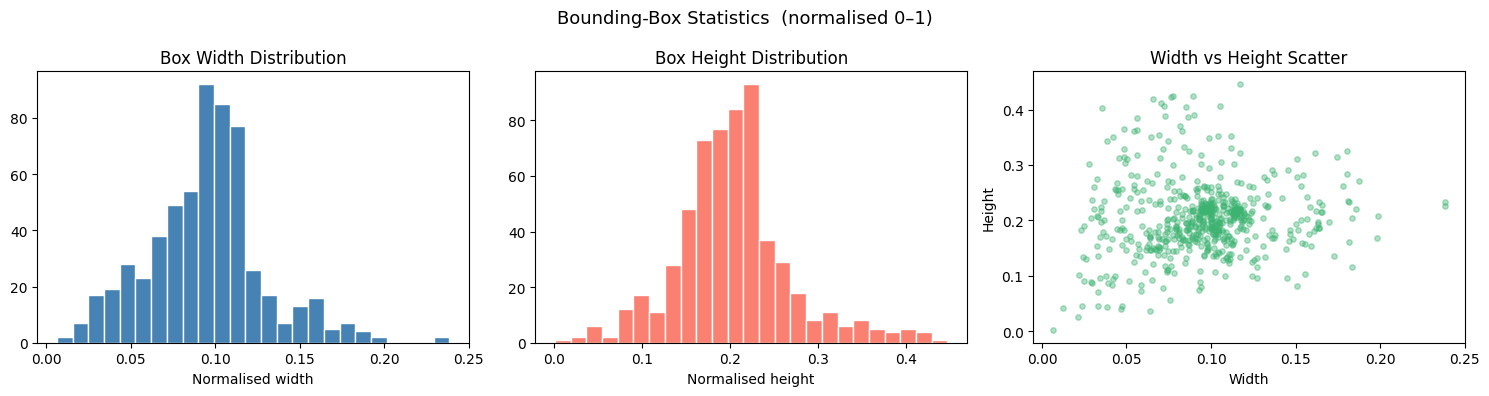

Mean box : 0.095 W  x  0.203 H  (normalised)


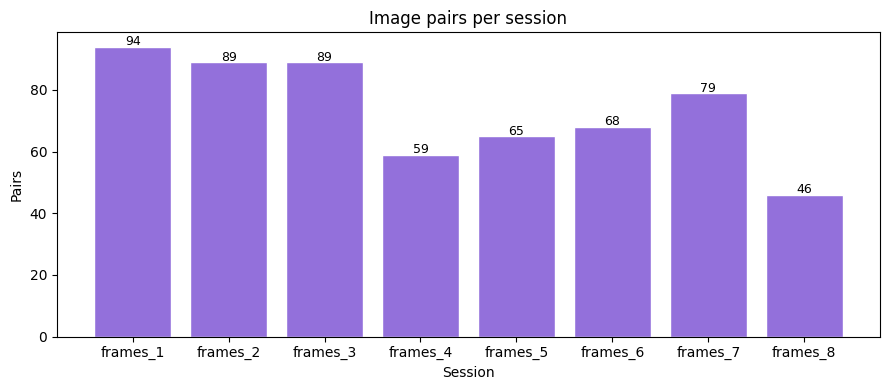

In [7]:
bw = np.array(bbox_widths)
bh = np.array(bbox_heights)

# ── BBox size distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Bounding-Box Statistics  (normalised 0–1)', fontsize=13)

axes[0].hist(bw, bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Box Width Distribution')
axes[0].set_xlabel('Normalised width')

axes[1].hist(bh, bins=25, color='salmon', edgecolor='white')
axes[1].set_title('Box Height Distribution')
axes[1].set_xlabel('Normalised height')

axes[2].scatter(bw, bh, alpha=0.4, s=15, color='mediumseagreen')
axes[2].set_title('Width vs Height Scatter')
axes[2].set_xlabel('Width')
axes[2].set_ylabel('Height')

plt.tight_layout()
plt.show()
print(f'Mean box : {bw.mean():.3f} W  x  {bh.mean():.3f} H  (normalised)')

# ── Pairs per session ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4))
sessions = sorted(session_counts)
counts   = [session_counts[s] for s in sessions]
ax2.bar(sessions, counts, color='mediumpurple', edgecolor='white')
ax2.set_title('Image pairs per session')
ax2.set_xlabel('Session')
ax2.set_ylabel('Pairs')
for i, v in enumerate(counts):
    ax2.text(i, v + 0.5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Visualise Annotations

Draws YOLO bounding boxes on randomly sampled frames from your actual data.

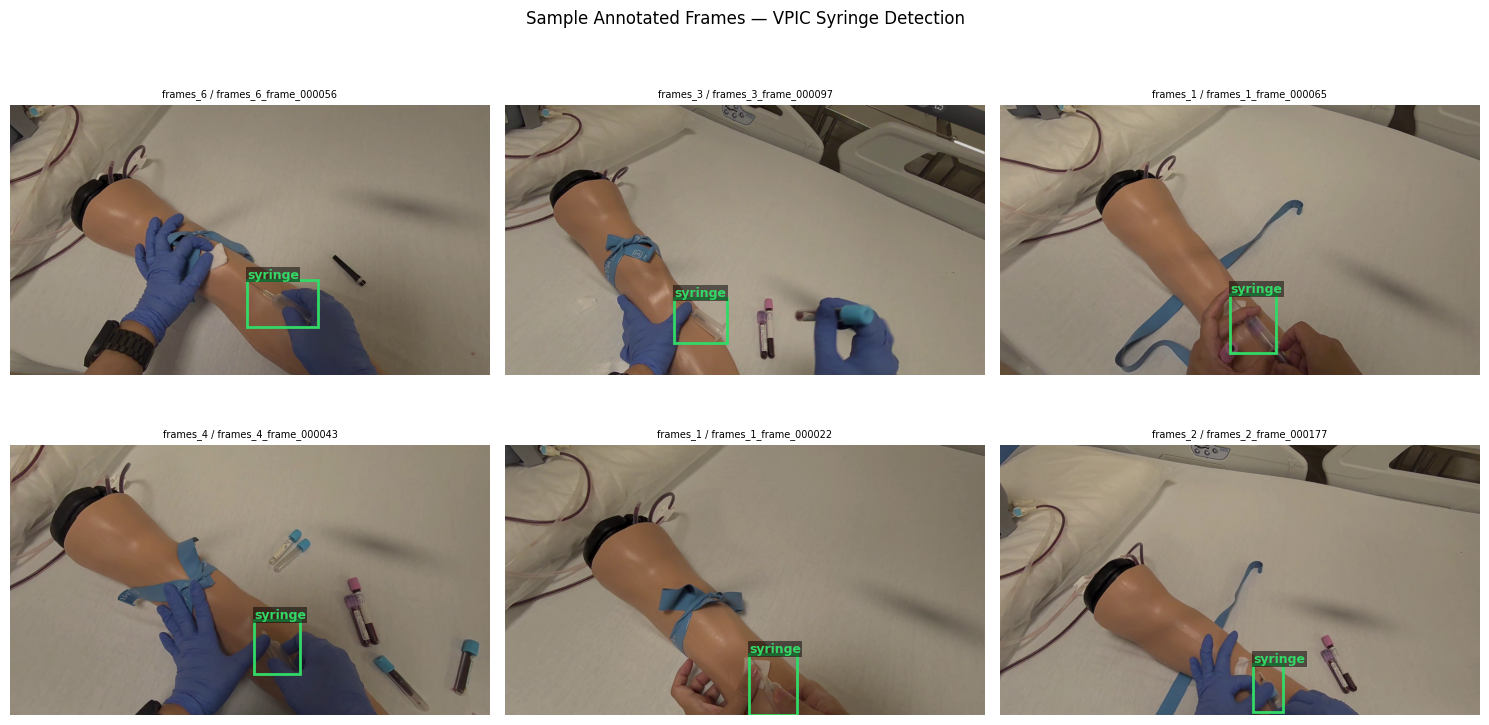

In [8]:
N_SAMPLES = 6

COLORS = {
    0: (0.20, 0.85, 0.40),   # syringe → green
    1: (1.00, 0.40, 0.40),
    2: (0.40, 0.60, 1.00),
}

def draw_yolo_boxes(ax, image_rgb, label_path, class_names):
    h, w = image_rgb.shape[:2]
    ax.imshow(image_rgb)
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5: continue
        cls_id = int(parts[0])
        cx, cy, bw, bh = map(float, parts[1:])
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        color = COLORS.get(cls_id, (1, 1, 0))
        ax.add_patch(patches.Rectangle(
            (x1, y1), bw*w, bh*h,
            linewidth=2, edgecolor=color, facecolor='none'
        ))
        label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        ax.text(x1, max(y1-4, 12), label, color=color, fontsize=9, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))
    ax.axis('off')

samples = random.sample(pairs, min(N_SAMPLES, len(pairs)))
cols = 3
rows = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = np.array(axes).flatten()

for ax, p in zip(axes, samples):
    img = cv2.imread(str(p['image']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    draw_yolo_boxes(ax, img, p['label'], CLASS_NAMES)
    ax.set_title(f"{p['session']} / {p['image'].stem}", fontsize=7)

for ax in axes[len(samples):]:
    ax.axis('off')

plt.suptitle('Sample Annotated Frames — VPIC Syringe Detection', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Train / Val / Test Split

Shuffles all pairs and splits 80 / 10 / 10.  
**Stratified by session** — each session contributes proportionally to every split,
so the model is evaluated on frames from all recording conditions.

In [9]:
random.seed(RANDOM_SEED)

train_pairs, val_pairs, test_pairs = [], [], []

for session in sorted(set(p['session'] for p in pairs)):
    sp = [p for p in pairs if p['session'] == session]
    random.shuffle(sp)
    n       = len(sp)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    train_pairs += sp[:n_train]
    val_pairs   += sp[n_train : n_train + n_val]
    test_pairs  += sp[n_train + n_val :]

splits = {'train': train_pairs, 'val': val_pairs, 'test': test_pairs}

print(f'Total pairs : {len(pairs)}')
print(f'  train     : {len(train_pairs)}')
print(f'  val       : {len(val_pairs)}')
print(f'  test      : {len(test_pairs)}')

Total pairs : 589
  train     : 469
  val       : 53
  test      : 67


---
## 6. Build YOLO Dataset Folder & `dataset.yaml`

Copies images and labels into the structure YOLOv8 expects:
```
vpic_dataset/
  images/train/   images/val/   images/test/
  labels/train/   labels/val/   labels/test/
  dataset.yaml
```

In [10]:
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for split_name in ('train', 'val', 'test'):
    (DATASET_DIR / 'images' / split_name).mkdir(parents=True)
    (DATASET_DIR / 'labels' / split_name).mkdir(parents=True)

for split_name, split_pairs in splits.items():
    for p in tqdm(split_pairs, desc=f'Copying {split_name:5s}'):
        shutil.copy(p['image'], DATASET_DIR / 'images' / split_name / p['image'].name)
        shutil.copy(p['label'], DATASET_DIR / 'labels' / split_name / p['label'].name)

yaml_path = DATASET_DIR / 'dataset.yaml'
cfg = {
    'path' : str(DATASET_DIR),
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : len(CLASS_NAMES),
    'names': CLASS_NAMES,
}
with open(yaml_path, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print('dataset.yaml:')
print('─' * 36)
print(yaml_path.read_text())
print('─' * 36)
print(f'Dataset ready at: {DATASET_DIR}')

Copying test : 100%|██████████| 67/67 [00:01<00:00, 44.55it/s]

dataset.yaml:
────────────────────────────────────
path: C:\Users\bluet\Documents\VPIC_ObjectDetection\vpic_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names:
- syringe

────────────────────────────────────
Dataset ready at: C:\Users\bluet\Documents\VPIC_ObjectDetection\vpic_dataset


---
## 7. Augmentation Preview

Shows 8 augmented versions of a real frame using Albumentations.  
Pipeline is tuned for the VPIC context:
- ✅ Horizontal flip — syringe can approach from either side
- ❌ No vertical flip — needle always points toward the vein
- Colour jitter — handles AR headset camera variance across lighting
- Motion blur — simulates hand movement during insertion

In [11]:
try:
    import albumentations as A
    ALBU = True
except ImportError:
    ALBU = False
    print('Run:  pip install albumentations')

if ALBU:
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=10, p=0.6),
        A.RandomResizedCrop(size=(640, 640), scale=(0.75, 1.0), p=0.5),
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05, p=0.7),
        A.GaussNoise(std_range=(0.02, 0.1), p=0.3),
        A.MotionBlur(blur_limit=5, p=0.2),
        A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(10, 30), hole_width_range=(10, 30), p=0.3),
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.4,
    ))
    print('Augmentation pipeline ready.')

Augmentation pipeline ready.


c:\Users\bluet\Documents\VPIC_ObjectDetection\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


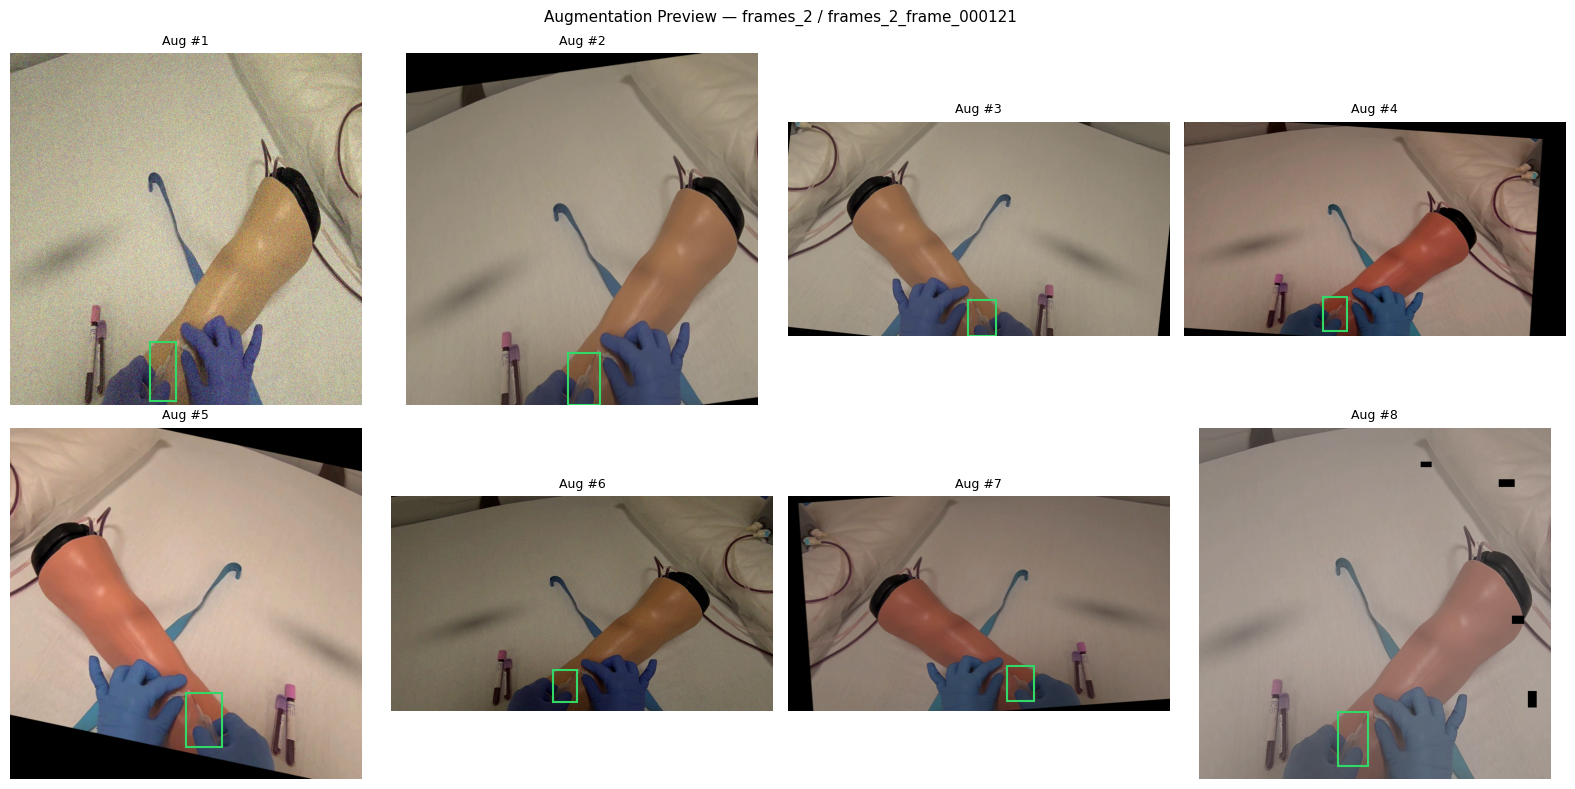

In [12]:
if ALBU:
    sample = random.choice(train_pairs)
    src_img = cv2.cvtColor(cv2.imread(str(sample['image'])), cv2.COLOR_BGR2RGB)

    bboxes, class_labels = [], []
    for line in sample['label'].read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            class_labels.append(int(parts[0]))
            bboxes.append([float(x) for x in parts[1:]])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        aug = train_transform(image=src_img.copy(), bboxes=bboxes, class_labels=class_labels)
        aug_img = aug['image']
        h, w = aug_img.shape[:2]
        ax.imshow(aug_img)
        for (cx, cy, bw, bh), cls_id in zip(aug['bboxes'], aug['class_labels']):
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            color = COLORS.get(cls_id, (1, 1, 0))
            ax.add_patch(patches.Rectangle((x1, y1), bw*w, bh*h,
                         linewidth=1.5, edgecolor=color, facecolor='none'))
        ax.set_title(f'Aug #{i+1}', fontsize=9)
        ax.axis('off')

    plt.suptitle(f"Augmentation Preview — {sample['session']} / {sample['image'].stem}", fontsize=11)
    plt.tight_layout()
    plt.show()

---
## 8. Sanity Check & Next Steps

In [13]:
print('Final dataset structure:')
print('─' * 50)
total_imgs = total_lbls = 0
for split_name in ('train', 'val', 'test'):
    imgs = list((DATASET_DIR / 'images' / split_name).iterdir())
    lbls = list((DATASET_DIR / 'labels' / split_name).glob('*.txt'))
    total_imgs += len(imgs)
    total_lbls += len(lbls)
    status = '✅' if len(imgs) == len(lbls) else '⚠️  MISMATCH'
    print(f'  {split_name:6s}  images: {len(imgs):4d}   labels: {len(lbls):4d}  {status}')
print('─' * 50)
print(f'  TOTAL   images: {total_imgs:4d}   labels: {total_lbls:4d}')
print(f'\ndataset.yaml → {yaml_path}')

Final dataset structure:
──────────────────────────────────────────────────
  train   images:  469   labels:  469  ✅
  val     images:   53   labels:   53  ✅
  test    images:   67   labels:   67  ✅
──────────────────────────────────────────────────
  TOTAL   images:  589   labels:  589

dataset.yaml → C:\Users\bluet\Documents\VPIC_ObjectDetection\vpic_dataset\dataset.yaml


---
## ✅ Pipeline Complete — Ready to Train

| Next notebook | Covers |
|---|---|
| `VPIC_Training.ipynb` | Fine-tune YOLOv8, loss curves, export `.pt` |
| `VPIC_Evaluation.ipynb` | mAP@0.5, confusion matrix, PR curves |
| `VPIC_Inference.ipynb` | Real-time stereo camera stream |
| `VPIC_ARExport.ipynb` | ONNX / TensorRT for Quest 3 / Vision Pro |

In [ ]:
# ── Start training when ready — uncomment and run ────────────────────────────
# from ultralytics import YOLO
#
# model = YOLO('yolov8n.pt')       # nano — fastest; swap to yolov8s.pt for better accuracy
# results = model.train(
#     data    = str(yaml_path),
#     epochs  = 100,
#     imgsz   = 640,
#     batch   = 16,
#     name    = 'vpic_syringe_v1',
#     patience= 20,
#     device  = 0 if torch.cuda.is_available() else 'cpu',
# )